# ***SATRIA DATA COMPETITION***

Video Clasification

In [ ]:
from google.colab import drive
import os
import warnings
warnings.filterwarnings('ignore')

drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/! Coding Workspace/2025_SF_Satria_Data')
print(os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/! Coding Workspace/2025_SF_Satria_Data


# NER (Named Entity Recognition)

In [ ]:
!pip install gliner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.3/76.3 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 85.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 117.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 99.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.0 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.1
    Uninstalling tokenizers-0.22.1:
      Successfully uninstalled tokenizers-0.22.1
  Attempting uninstall: transformers
    Found existing installation: transformers 4.56.2
    Uninstalling transformers-4.56.2:
      Successfully uninstalled transformers-4.56.2


In [ ]:
import os, json, re, math, traceback
from typing import List, Dict, Tuple, Union
import pandas as pd
from tqdm.auto import tqdm
import torch

# ====== CONFIG ======
INPUT_CSV   = "./data/df_all_data.csv"
OUTPUT_CSV  = "./data/data_with_entities.csv"

TEXT_COL     = "text"
SUMMARY_COL  = "summary_2para"
CAPTION_COL  = "caption_id"

GLINER_MODEL_ID = "urchade/gliner_multi-v2.1"
GLINER_FALLBACK = "urchade/gliner_multilingual_v1"

LABELS = [
    "Person", "Org", "Loc",
    "Brand", "Product", "Event",
    "Date", "Time", "Money", "Percent",
    "Hashtag", "Username", "URL"
]
SCORE_THRESHOLD = 0.35

# fixed-size chunking
MAX_CHARS    = 2000
STRIDE_CHARS = 300

SAVE_EVERY = 1

In [ ]:
# ====== MODEL ======
try:
    from gliner import GLiNER
except ImportError:
    raise SystemExit("GLiNER belum terpasang. Jalankan: pip install gliner")

def gliner_load(model_id: str):
    print(f"[INFO] Loading GLiNER: {model_id}")
    m = GLiNER.from_pretrained(model_id)
    m.eval()
    try:
        print(f"[INFO] Using device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")
    except Exception:
        pass
    return m

# ====== CHUNK & SPAN UTILS ======
def fixed_chunks(text: str, max_chars=MAX_CHARS, stride=STRIDE_CHARS) -> List[Dict]:
    text = (text or "")
    if not text.strip():
        return []
    chunks, i, n = [], 0, len(text)
    while i < n:
        j = min(i + max_chars, n)
        chunks.append({"text": text[i:j], "start": i, "end": j})
        if j == n: break
        i = max(0, j - stride)
    return chunks

def spans_overlap(a, b):
    return not (a["end"] <= b["start"] or b["end"] <= a["start"])

def merge_spans(spans: List[Dict]) -> List[Dict]:
    if not spans: return []
    spans = sorted(spans, key=lambda x: (x["start"], -(x["end"]-x["start"]), -float(x.get("score",0))))
    merged = []
    for s in spans:
        if not merged:
            merged.append(s); continue
        last = merged[-1]
        if spans_overlap(last, s) and last["label"] == s["label"]:
            len_last = last["end"] - last["start"]
            len_s    = s["end"]  - s["start"]
            if len_s > len_last or (len_s == len_last and float(s.get("score",0)) > float(last.get("score",0))):
                merged[-1] = s
        else:
            merged.append(s)
    return merged

def union_spans(a: List[Dict], b: List[Dict]) -> List[Dict]:
    out = {}
    def put(e):
        if not all(k in e for k in ("text","label","start","end")): return
        key = (e["text"].lower(), e["label"])
        cand_len = e["end"] - e["start"]
        if key not in out:
            out[key] = e
        else:
            old = out[key]
            old_len = old["end"] - old["start"]
            if cand_len > old_len or (cand_len == old_len and float(e.get("score",0)) > float(old.get("score",0))):
                out[key] = e
    for s in (a or []): put(s)
    for s in (b or []): put(s)
    return sorted(out.values(), key=lambda x: (x["label"], x["start"], x["text"].lower()))

def union_many(*lists: List[List[Dict]]) -> List[Dict]:
    merged = []
    for L in lists:
        merged = union_spans(merged, L or [])
    return merged

# ====== CAPTION PARSER ======
def parse_caption_field(val: Union[str, float]) -> Tuple[str, List[str]]:
    """
    Return:
      - caption_joined: gabungan semua caption jadi 1 string (dipakai untuk union caption)
      - cap_items: list of caption strings (untuk 'entities_caption_each')
    Terima:
      - string biasa
      - JSON list string (mis. '["cap1","cap2"]')
      - NaN/empty
    """
    if val is None or (isinstance(val, float) and pd.isna(val)):
        return "", []
    s = str(val).strip()
    if not s:
        return "", []
    # coba parse json list
    try:
        obj = json.loads(s)
        if isinstance(obj, list):
            items = [str(x) for x in obj if str(x).strip()]
            return "\n".join(items), items
    except Exception:
        pass
    # bukan list JSON → anggap single caption string
    return s, [s]


In [ ]:
# ====== PREDICT ======
def predict_fulltext(model, text: str, labels, thr=SCORE_THRESHOLD) -> List[Dict]:
    if not text or not text.strip():
        return []
    try:
        pieces = fixed_chunks(text, MAX_CHARS, STRIDE_CHARS)
        res = []
        for ch in pieces:
            ents = model.predict_entities(ch["text"], labels=labels, threshold=thr)
            for e in ents:
                res.append({
                    "text":  e["text"],
                    "start": int(e["start"]) + ch["start"],
                    "end":   int(e["end"])   + ch["start"],
                    "label": e["label"],
                    "score": float(e.get("score", 1.0)),
                })
        return merge_spans(res)
    except Exception as e:
        return [{"error": repr(e), "trace": traceback.format_exc(limit=1)}]

def safe_save_csv(df: pd.DataFrame, path: str):
    tmp = path + ".tmp"
    df.to_csv(tmp, index=False, encoding="utf-8-sig")
    os.replace(tmp, path)

# ====== LOAD MODEL ======
try:
    model = gliner_load(GLINER_MODEL_ID)
except Exception as e:
    print(f"[WARN] gagal load {GLINER_MODEL_ID}: {e}\n[INFO] mencoba fallback {GLINER_FALLBACK}")
    model = gliner_load(GLINER_FALLBACK)

# paksa ke GPU jika ada
device = "cuda" if torch.cuda.is_available() else "cpu"
try:
    model.to(device)
except Exception:
    try:
        model.model.to(device)  # type: ignore
    except Exception:
        pass


In [ ]:
# ====== IO & RESUME ======
assert os.path.exists(INPUT_CSV), f"File input tidak ditemukan: {INPUT_CSV}"

def ensure_cols(df: pd.DataFrame, cols: List[str]):
    for c in cols:
        if c not in df.columns:
            df[c] = ""

if os.path.exists(OUTPUT_CSV):
    out_df = pd.read_csv(OUTPUT_CSV)
    in_df  = pd.read_csv(INPUT_CSV)
    # pakai output kalau cocok, else merge on 'id'
    if len(out_df) == len(in_df) and all(col in out_df.columns for col in in_df.columns):
        df = out_df
        ensure_cols(df, [
            "entities_raw","entities_sum","entities_union",
            "entities_caption_each","entities_caption_union","entities_union_all"
        ])
    else:
        df = in_df.copy()
        if "id" in out_df.columns and "id" in df.columns:
            keep = [c for c in ["id",
                                "entities_raw","entities_sum","entities_union",
                                "entities_caption_each","entities_caption_union","entities_union_all"]
                    if c in out_df.columns]
            df = df.merge(out_df[keep], on="id", how="left")
        ensure_cols(df, [
            "entities_raw","entities_sum","entities_union",
            "entities_caption_each","entities_caption_union","entities_union_all"
        ])
else:
    df = pd.read_csv(INPUT_CSV)
    ensure_cols(df, [
        "entities_raw","entities_sum","entities_union",
        "entities_caption_each","entities_caption_union","entities_union_all"
    ])

# sanity checks
assert TEXT_COL in df.columns,    f"Kolom '{TEXT_COL}' tidak ada di CSV!"
assert SUMMARY_COL in df.columns, f"Kolom '{SUMMARY_COL}' tidak ada di CSV!"
assert CAPTION_COL in df.columns, f"Kolom '{CAPTION_COL}' tidak ada di CSV!"
total = len(df)

# kita lanjut baris yang BELUM punya union_all
to_do_idx = [i for i in range(total)
             if not (isinstance(df.at[i, "entities_union_all"], str) and df.at[i, "entities_union_all"].strip())]

print(f"[INFO] Mulai/lanjut NER: total {total} baris, sisa: {len(to_do_idx)} → {OUTPUT_CSV}")


In [ ]:
# ====== LOOP ======
since_save = 0
for i in tqdm(to_do_idx, desc="NER (raw + summary + caption)"):
    text    = str(df.at[i, TEXT_COL]) if TEXT_COL in df.columns else ""
    summary = str(df.at[i, SUMMARY_COL]) if SUMMARY_COL in df.columns else ""

    cap_raw  = df.at[i, CAPTION_COL] if CAPTION_COL in df.columns else ""
    cap_join, cap_items = parse_caption_field(cap_raw)

    # Pass-1: raw & summary
    ents_raw = predict_fulltext(model, text, LABELS, SCORE_THRESHOLD)
    ents_sum = predict_fulltext(model, summary, LABELS, SCORE_THRESHOLD) if summary.strip() else []

    # Pass-2: caption (per item + union caption)
    ents_cap_each = []
    for cap in cap_items:
        ents_cap_each.append(predict_fulltext(model, cap, LABELS, SCORE_THRESHOLD))
    ents_cap_union = predict_fulltext(model, cap_join, LABELS, SCORE_THRESHOLD) if cap_join.strip() else []

    # union lama (raw+sum) untuk kompatibilitas
    try:
        ents_union = union_spans(
            [e for e in ents_raw if "start" in e],
            [e for e in ents_sum if "start" in e]
        )
    except Exception as e:
        ents_union = [{"error": f"union_failed: {repr(e)}"}]

    # union all (raw + summary + caption_union)
    try:
        ents_union_all = union_many(ents_raw, ents_sum, ents_cap_union)
    except Exception as e:
        ents_union_all = [{"error": f"union_all_failed: {repr(e)}"}]

    # simpan kolom
    df.at[i, "entities_raw"]            = json.dumps(ents_raw, ensure_ascii=False)
    df.at[i, "entities_sum"]            = json.dumps(ents_sum, ensure_ascii=False)
    df.at[i, "entities_union"]          = json.dumps(ents_union, ensure_ascii=False)           # raw+sum
    df.at[i, "entities_caption_each"]   = json.dumps(ents_cap_each, ensure_ascii=False)        # list of lists
    df.at[i, "entities_caption_union"]  = json.dumps(ents_cap_union, ensure_ascii=False)       # union caption
    df.at[i, "entities_union_all"]      = json.dumps(ents_union_all, ensure_ascii=False)       # raw+sum+caption

    since_save += 1
    if since_save >= SAVE_EVERY:
        safe_save_csv(df, OUTPUT_CSV)
        since_save = 0

# save final
safe_save_csv(df, OUTPUT_CSV)
print("[INFO] Selesai →", OUTPUT_CSV)

# sanity check
print(df[["id", "entities_union_all"]].head(5))


[INFO] Loading GLiNER: urchade/gliner_multi-v2.1


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

[INFO] Using device: CUDA
[INFO] Mulai/lanjut NER: total 998 baris, sisa: 919 → ./data/data_with_entities.csv


NER (raw + summary + caption):   0%|          | 0/919 [00:00<?, ?it/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


[INFO] Selesai → ./data/data_with_entities.csv
   id                                 entities_union_all
0   1  [{"text": "squat", "start": 73, "end": 78, "la...
1   2  [{"text": "rasa sakit", "start": 24, "end": 34...
2   3  [{"text": "Dog Fast Run 2025", "start": 125, "...
3   4  [{"text": "kesalahan", "start": 448, "end": 45...
4   5  [{"text": "Hasil akhir pertandingan", "start":...


In [ ]:
df_output = pd.read_csv(OUTPUT_CSV)
df_output[['id', 'text','entities_raw','entities_sum','entities_union']].query('entities_sum.notna()').tail(2)

,id,text,entities_raw,entities_sum,entities_union
996,999,Pertarungan Tidak Mencoba Pertama-tama bersyu...,"[{""text"": ""World Tour 500 Place"", ""start"": 383...","[{""text"": ""Pemain badminton Indonesia"", ""start...","[{""text"": ""World Tour 500 Place"", ""start"": 69,..."
997,1000,CABANG OLAHRAGA LAIAR DKI JAKARTA berhasil me...,"[{""text"": ""PON 21 Aceh Sunut 2024"", ""start"": 9...","[{""text"": ""CABANG OLAHRAGA LAIAR DKI JAKARTA"",...","[{""text"": ""14 September 2024"", ""start"": 1101, ..."


In [ ]:
df_output['entities_union_all'].iloc[25]

'[{"text": "layanan pertama", "start": 81, "end": 96, "label": "Event", "score": 0.5910553932189941}, {"text": "tertutup", "start": 40, "end": 48, "label": "Loc", "score": 0.42365381121635437}, {"text": "garis kedua", "start": 99, "end": 110, "label": "Loc", "score": 0.5368019342422485}, {"text": "depan", "start": 125, "end": 130, "label": "Loc", "score": 0.7235081195831299}, {"text": "belakang", "start": 161, "end": 169, "label": "Loc", "score": 0.36090928316116333}, {"text": "lapangan", "start": 226, "end": 234, "label": "Loc", "score": 0.9637342691421509}, {"text": "dua orang", "start": 147, "end": 156, "label": "Person", "score": 0.8761693239212036}, {"text": "kalian", "start": 268, "end": 274, "label": "Person", "score": 0.6719628572463989}, {"text": "Pemain", "start": 317, "end": 323, "label": "Person", "score": 0.9549222588539124}, {"text": "Peserta", "start": 393, "end": 400, "label": "Person", "score": 0.9768543839454651}, {"text": "orang", "start": 395, "end": 400, "label": "

## CONVERT JSON TO TABLE

In [ ]:
INPUT_CSV   = "./data/data_with_summary.csv"   # kolom: id,file,emotion,text,summary_2para (opsional)
OUTPUT_CSV  = "./data/data_with_entities.csv"

In [ ]:
import json, re
import pandas as pd
from collections import defaultdict

PATH = "./data/data_with_entities.csv"
df = pd.read_csv(PATH)

# helper aman: parse JSON string -> list[dict]
def parse_entities(x):
    try:
        if isinstance(x, str) and x.strip():
            v = json.loads(x)
            # pastikan benar list of dict
            if isinstance(v, list):
                return [e for e in v if isinstance(e, dict) and "text" in e and "label" in e]
    except Exception:
        pass
    return []

df["_ents_raw"] = df["entities_union"].apply(parse_entities)


In [ ]:
COMMON_PERSON = {"lansia","ibu","bapak","teman","kakak",
                 "adik","om","tante","guys","bro","sis","gue", "saya", "aku",
                 "kamu", "kita", "anda","Bang", "Pak", "lo", "Aku", "Anda", "kami",
                 "Gue", "lu", "Aku", "Saya", "dia", "Pak", "penulis"}

def clean_entities(ents):
    out = []
    for e in ents:
        lab = e["label"].lower()
        txt = e["text"].strip()
        if lab == "person" and (txt.islower() and " " not in txt) and txt.lower() in COMMON_PERSON:
            continue
        if lab == "loc" and txt.islower():
            continue
        if lab == "event":  # kalau tidak diperlukan
            continue
        out.append(e)
    return out

df["_ents_raw"] = df["_ents_raw"].apply(clean_entities)


In [ ]:
# ambil daftar label yang ada
all_labels = sorted({e["label"] for ents in df["_ents_raw"] for e in ents})

def texts_by_label(ents):
    buckets = defaultdict(list)
    seen = set()
    for e in ents:
        key = (e["label"], e["text"].strip())
        if key in seen:
            continue
        seen.add(key)
        buckets[e["label"]].append(e["text"].strip())
    return buckets

buckets_series = df["_ents_raw"].apply(texts_by_label)

# buat kolom list per label, plus versi string join (opsional)
for lab in all_labels:
    df[f"ents_{lab}"] = buckets_series.apply(lambda d: d.get(lab, []))
    df[f"ents_{lab}_str"] = df[f"ents_{lab}"].apply(lambda L: "; ".join(L) if L else "")

# contoh: lihat kolom yang terbentuk
cols_show = ["id"] + [f"ents_{lab}_str" for lab in all_labels]
df[cols_show].head()


,id,ents_Brand_str,ents_Date_str,ents_Hashtag_str,ents_Loc_str,ents_Money_str,ents_Org_str,ents_Percent_str,ents_Person_str,ents_Product_str,ents_Time_str,ents_URL_str,ents_Username_str
0,1,,,,,,,,,dumbbell,2-3 kali seminggu,,
1,2,,,,,,,,,Pro8G,,,
2,3,,,,Bandung,25.000,,,Pengguna; nama gue,Pilkita; grafier mendali,37 menit,,Pengguna
3,4,,,,,,,,Penulis; pasangannya; lawan; lawannya; Vika; p...,,part 1; part 2,,
4,5,,,,,,,,Batin Fan; mereka; gua; pemain; kalian; lawann...,,,,


In [ ]:
keep = ["Person","Org","Loc","Product","Brand","Date","Time","Money"]
for lab in all_labels:
    if lab not in keep:
        df.drop(columns=[f"ents_{lab}", f"ents_{lab}_str"], errors="ignore", inplace=True)


In [ ]:
# ambil daftar label yang ada setelah filtering
all_labels_kept = [lab for lab in all_labels if lab in keep]

# contoh: lihat kolom yang terbentuk setelah filtering
cols_show = ["id"] + [f"ents_{lab}_str" for lab in all_labels_kept]
df[cols_show].head()

,id,ents_Brand_str,ents_Date_str,ents_Loc_str,ents_Money_str,ents_Org_str,ents_Person_str,ents_Product_str,ents_Time_str
0,1,,,,,,seorang anak; seorang wanita; seorang pria,dumbbell,2-3 kali seminggu
1,2,,,,,,orang; seorang pria,Pro8G,
2,3,,,Bandung,25.000,,Seorang pria; seorang wanita; Pengguna; nama gue,Pilkita; grafier mendali,37 menit
3,4,,,,,,Penulis; pasangannya; dua orang; lawan; lawann...,,part 1; part 2
4,5,,,,,,Batin Fan; mereka; gua; pemain; kalian; dua or...,badminton,


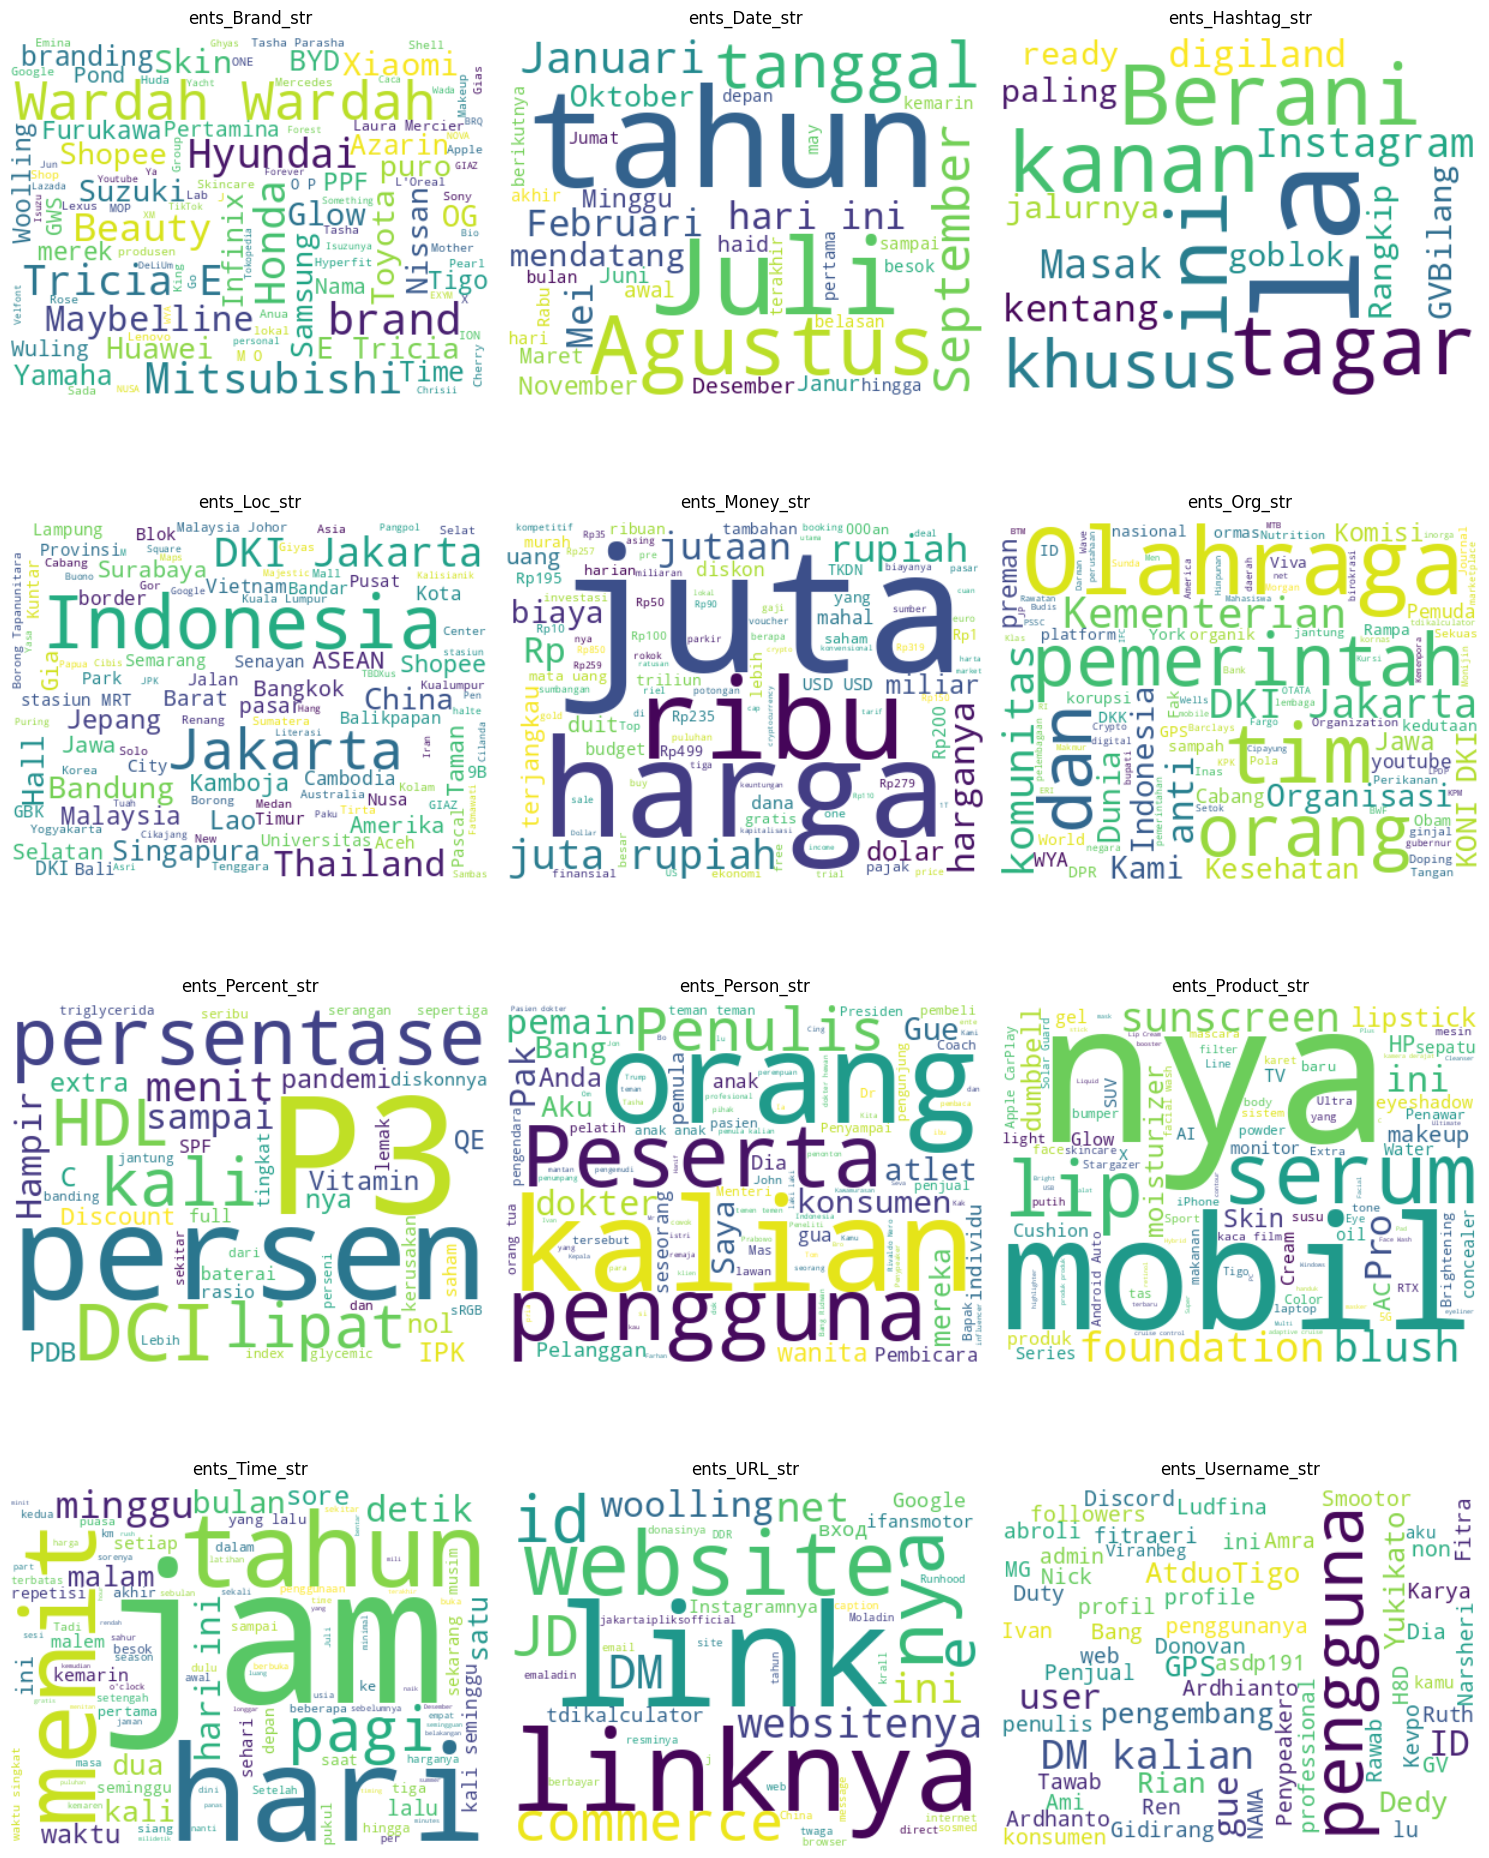

In [ ]:
from wordcloud import WordCloud

import matplotlib.pyplot as plt

df_ner = df[cols_show]

# Get all NER columns (excluding 'id')
ner_columns = [col for col in df_ner.columns if col != 'id']

# Create subplots
n_columns = len(ner_columns)
cols = 3
rows = (n_columns + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes

for i, column in enumerate(ner_columns):
    # Get all non-null values from the column
    column_data = df_ner[column].dropna()

    # Split by ';' and combine all words
    all_words = []
    for entry in column_data:
        words = [word.strip() for word in str(entry).split(';')]
        all_words.extend(words)

    # Join all words into one text
    combined_text = ' '.join(all_words)

    if combined_text.strip():  # Only create wordcloud if there's text
        # Create wordcloud
        wordcloud = WordCloud(
            width=400,
            height=300,
            background_color='white',
            colormap='viridis',
            max_words=100
        ).generate(combined_text)

        # Plot wordcloud
        axes[i].imshow(wordcloud, interpolation='bilinear')
    else:
        axes[i].text(0.5, 0.5, 'No Data', ha='center', va='center', transform=axes[i].transAxes)

    axes[i].set_title(column, fontsize=12, pad=10)
    axes[i].axis('off')

# Hide empty subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
df[cols_show].to_csv('./data/NER_result_raw.csv', index=False)